# Week 14: 데이터 전처리와 과적합 대응
**Part 1. 데이터 전처리**
**Part 2. 과적합 진단**  
**Part 3. 정규화 4가지 방법**
**Part 4. 종합 실습**

**오늘의 데이터**: UCI Appliances Energy Prediction (회귀)

## 0. 환경 준비

라이브러리 임포트 및 random seed 고정.

In [1]:
import os
os.environ['KERAS_BACKEND'] = 'torch'      # ← TF 대신 PyTorch 백엔드 사용 (TF 설치 불필요)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras                                # 독립형 Keras 3 (백엔드는 위에서 torch로 지정)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

# 재현성을 위한 seed 고정
np.random.seed(42)
keras.utils.set_random_seed(42)             # tf.random.set_seed(42) 대체 (py/numpy/torch 동시 고정)

print('Keras  :', keras.__version__, '| backend:', keras.backend.backend())
print('pandas :', pd.__version__)

I0000 00:00:1780662273.420873    2370 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Keras  : 3.14.1 | backend: torch
pandas : 3.0.2


I0000 00:00:1780662276.531549    2370 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780662276.535187    2370 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


---
# Part 1. 데이터 전처리

## 1.0 왜 전처리가 먼저인가

지난 주 Boston/MNIST는 *이미 깨끗한 데이터*였다.
실제 데이터는 다르다 — 결측치, 이상치, 범주형 변수, 스케일이 다른 수치형 변수가 섞여 있다.

> **모델이 좋은 게 아니라, 전처리가 좋은 것이다.** (Andrew Ng: "Data-centric AI")

## 1.1 결측치 처리

### 결측치 탐지

In [2]:
# 예시용 toy 데이터프레임 (결측치 포함)
toy = pd.DataFrame({
    'age':    [25, 30, np.nan, 45, 28],
    'salary': [50, np.nan, 70, 80, 55],
    'city':   ['Seoul', 'Busan', 'Seoul', None, 'Incheon']
})

print('원본 데이터:')
print(toy)
print()
print('각 컬럼별 결측치 개수:')
print(toy.isnull().sum())

원본 데이터:
    age  salary     city
0  25.0    50.0    Seoul
1  30.0     NaN    Busan
2   NaN    70.0    Seoul
3  45.0    80.0      NaN
4  28.0    55.0  Incheon

각 컬럼별 결측치 개수:
age       1
salary    1
city      1
dtype: int64


### 처리 전략 3가지

| 방법 | 코드 | 언제 쓰나 |
|------|------|----------|
| **삭제** | `df.dropna()` | 결측치가 적을 때 (<5%) |
| **대체 (수치)** | `df['age'].fillna(df['age'].mean())` | 정규분포에 가까울 때 |
| **대체 (범주)** | `df['city'].fillna('Unknown')` | 범주형 변수 |

In [3]:
# 전략 1: 삭제 (결측치 있는 행 제거)
print('삭제 결과 (dropna):')
print(toy.dropna())
print()

# 전략 2 & 3: 대체
toy_filled = toy.copy()
toy_filled['age']    = toy_filled['age'].fillna(toy_filled['age'].mean())      # 평균 대체
toy_filled['salary'] = toy_filled['salary'].fillna(toy_filled['salary'].median())  # 중앙값
toy_filled['city']   = toy_filled['city'].fillna('Unknown')                    # 새 범주

print('대체 결과 (fillna):')
print(toy_filled)

삭제 결과 (dropna):
    age  salary     city
0  25.0    50.0    Seoul
4  28.0    55.0  Incheon

대체 결과 (fillna):
    age  salary     city
0  25.0    50.0    Seoul
1  30.0    62.5    Busan
2  32.0    70.0    Seoul
3  45.0    80.0  Unknown
4  28.0    55.0  Incheon


> ⚠️ **중요 — Data Leakage 방지**
>
> 대체값(평균, 중앙값)은 **train 데이터에서만** 계산해야 한다.
> test의 평균을 쓰면 미래 정보가 학습에 누수됨 (data leakage).

## 1.2 수치형 정규화

### 왜 정규화하나?

```
변수 A: [1, 2, 3, 4]        ← 작은 스케일
변수 B: [100, 200, 300, 400] ← 큰 스케일
```

신경망은 큰 값에 *과민*하게 반응 → 학습 불안정.

### 두 가지 방법

| Scaler | 변환 후 범위 | 수식 | 언제 |
|--------|-------------|------|------|
| **MinMaxScaler** | [0, 1] | `(x - min) / (max - min)` | 이미지 픽셀, 경계 명확 |
| **StandardScaler** | 평균 0, 분산 1 | `(x - mean) / std` | 정규분포에 가까울 때 |

In [4]:
# 예시 데이터
data = np.array([[1.0, 100.0],
                 [2.0, 200.0],
                 [3.0, 300.0],
                 [4.0, 400.0]])

# StandardScaler
ss = StandardScaler().fit_transform(data)
print('StandardScaler 결과 (평균 0, 분산 1):')
print(ss)
print()

# MinMaxScaler
mm = MinMaxScaler().fit_transform(data)
print('MinMaxScaler 결과 ([0, 1] 범위):')
print(mm)

StandardScaler 결과 (평균 0, 분산 1):
[[-1.34164079 -1.34164079]
 [-0.4472136  -0.4472136 ]
 [ 0.4472136   0.4472136 ]
 [ 1.34164079  1.34164079]]

MinMaxScaler 결과 ([0, 1] 범위):
[[0.         0.        ]
 [0.33333333 0.33333333]
 [0.66666667 0.66666667]
 [1.         1.        ]]


### 올바른 사용법

```python
# train에 fit, val/test는 transform만
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform
X_val_scaled   = scaler.transform(X_val)         # ⚠️ fit 안 함!
X_test_scaled  = scaler.transform(X_test)        # ⚠️ fit 안 함!
```

> ⚠️ **fit은 train에만**, val/test는 `transform`만. (data leakage 방지)

## 1.3 범주형 인코딩

### (a) One-Hot Encoding — 순서 없는 범주형

In [5]:
sample = pd.DataFrame({
    'color': ['red', 'blue', 'green', 'red'],
    'size':  ['S', 'M', 'L', 'XL']
})
print('원본:')
print(sample)
print()

# One-Hot: 순서 없는 변수에 적합 (color, city, gender)
print('One-Hot Encoding:')
print(pd.get_dummies(sample, columns=['color']))

원본:
   color size
0    red    S
1   blue    M
2  green    L
3    red   XL

One-Hot Encoding:
  size  color_blue  color_green  color_red
0    S       False        False       True
1    M        True        False      False
2    L       False         True      False
3   XL       False        False       True


### (b) Ordinal Encoding — 순서 있는 범주형

In [6]:
# Ordinal: 순서가 의미 있는 변수에 적합 (size, grade, education)
size_map = {'S': 0, 'M': 1, 'L': 2, 'XL': 3}
sample2 = sample.copy()
sample2['size_ord'] = sample2['size'].map(size_map)
print('Ordinal Encoding:')
print(sample2)

Ordinal Encoding:
   color size  size_ord
0    red    S         0
1   blue    M         1
2  green    L         2
3    red   XL         3


### (c) Label Encoding — 분류 *타겟*에 사용

In [7]:
# 분류 문제의 정답(target) 인코딩
le = LabelEncoder()
y_encoded = le.fit_transform(['cat', 'dog', 'cat', 'bird'])
print('원본 라벨:', ['cat', 'dog', 'cat', 'bird'])
print('인코딩 결과:', y_encoded)
print('클래스 순서:', le.classes_)

원본 라벨: ['cat', 'dog', 'cat', 'bird']
인코딩 결과: [1 2 1 0]
클래스 순서: ['bird' 'cat' 'dog']


### 어느 걸 쓸까?

```
변수가 "순서"를 가지는가?
├─ 예 (size, grade)    ──→ Ordinal
└─ 아니오 (color, city) ──→ One-Hot

이건 분류 문제의 "정답"인가?
└─ 예 ──→ LabelEncoder (또는 keras.utils.to_categorical로 one-hot)
```

## 1.4 시간 변수 처리

`datetime`을 *수치형 feature*로 분해.

In [8]:
# 예시 시간 데이터
time_df = pd.DataFrame({
    'date': pd.date_range('2024-01-01', periods=5, freq='6h')
})

# datetime 분해
time_df['year']       = time_df['date'].dt.year
time_df['month']      = time_df['date'].dt.month       # 1~12
time_df['day']        = time_df['date'].dt.day         # 1~31
time_df['hour']       = time_df['date'].dt.hour        # 0~23
time_df['dayofweek']  = time_df['date'].dt.dayofweek   # 0=월요일, 6=일요일
time_df['is_weekend'] = (time_df['dayofweek'] >= 5).astype(int)

print(time_df)

                 date  year  month  day  hour  dayofweek  is_weekend
0 2024-01-01 00:00:00  2024      1    1     0          0           0
1 2024-01-01 06:00:00  2024      1    1     6          0           0
2 2024-01-01 12:00:00  2024      1    1    12          0           0
3 2024-01-01 18:00:00  2024      1    1    18          0           0
4 2024-01-02 00:00:00  2024      1    2     0          1           0


> 💡 **Tip**: 시간 변수가 *순환적*(23시 다음은 0시)이라는 점을 모델에 알려주려면 sin/cos 변환을 쓸 수 있지만, 오늘은 단순 분해만 다룬다.

## 1.5 Train/Val/Test 3분할

### 왜 3분할인가?

Week 13에서는 train/test 2분할만 썼다. 이건 *간단한 예제에서만* OK.

```
2분할의 문제:
  Train ─→ 모델 학습
  Test ─→ 하이퍼파라미터 튜닝
         ↑↑↑ 이 시점에 test가 "새는" 셈
→ 최종 성능을 평가할 깨끗한 데이터가 없어진다.
```

### 3분할

```
Train ─→ 모델 학습 (가중치 업데이트)
Val   ─→ 하이퍼파라미터 결정 + 과적합 진단
Test  ─→ 마지막 단 한 번만 평가 (절대 건드리지 않음)
```

In [9]:
# 예시용 가짜 데이터로 3분할 시연
X_demo = np.random.randn(1000, 5)
y_demo = np.random.randn(1000)

# 1단계: train+val vs test (80:20)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_demo, y_demo, test_size=0.2, random_state=42
)

# 2단계: train vs val (80:20 of temp)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42
)

# 결과: 64% train, 16% val, 20% test
print(f'Train: {X_train.shape}  ({len(X_train)/1000:.0%})')
print(f'Val  : {X_val.shape}  ({len(X_val)/1000:.0%})')
print(f'Test : {X_test.shape}  ({len(X_test)/1000:.0%})')

Train: (640, 5)  (64%)
Val  : (160, 5)  (16%)
Test : (200, 5)  (20%)


### Keras에서의 사용

```python
model.fit(X_train, y_train,
          validation_data=(X_val, y_val),   # ← val 명시적 전달
          epochs=100, batch_size=32)
```

## ✅ Part 1 정리

1. **결측치**: 탐지 → 삭제 또는 대체. *train에서만* 통계 계산.
2. **수치형**: `StandardScaler` 가 기본. *train에 fit, val/test는 transform*.
3. **범주형**: 순서 있으면 Ordinal, 없으면 One-Hot.
4. **시간**: datetime을 hour/dayofweek 등으로 분해.
5. **3분할**: train(학습) / val(튜닝) / test(최종 평가).

> 💡 Week 13까지의 코드에는 이 중 #2(MinMax)와 #5의 *2분할*만 있었다.
> 오늘부터는 5가지 모두를 표준으로 쓴다.

---
# Part 2. 과적합 진단

## 2.1 과적합이란

```
좋은 모델: train에서 잘 맞추고, 새 데이터에서도 잘 맞춤
과적합:   train에서만 잘 맞추고, 새 데이터에서는 못 맞춤
         (= "암기"는 했는데 "이해"는 못 한 상태)
```

### Bias-Variance Trade-off

| 상태 | Train Loss | Val Loss | 진단 / 처방 |
|------|-----------|----------|------------|
| **Underfit** | 높음 | 높음 | 모델 너무 단순 → *모델 키우기* |
| **Good fit** | 낮음 | 낮음 | 적절 |
| **Overfit** | 매우 낮음 | 높음 | 모델 너무 복잡 → *정규화* |

## 2.2 데이터 로드 + 전처리 (Energy Consumption)

이제 실제 데이터로 실습한다.
**UCI Appliances Energy Prediction** — 가전제품 에너지 사용량 예측 (회귀).
- 19,735 샘플, 26 features (실내 9개 방 온도/습도 + 외부 기상)

In [10]:
# 데이터 로드
url = 'https://raw.githubusercontent.com/LuisM78/Appliances-energy-prediction-data/master/energydata_complete.csv'
df = pd.read_csv(url)
df['date'] = pd.to_datetime(df['date'])

# 시간 변수 추출 (Part 1.4)
df['hour']      = df['date'].dt.hour
df['dayofweek'] = df['date'].dt.dayofweek
df['month']     = df['date'].dt.month

# Feature/target 분리
feature_cols = ['T1', 'RH_1', 'T2', 'RH_2', 'T_out', 'RH_out',
                'Windspeed', 'Visibility',
                'hour', 'dayofweek', 'month']
X = df[feature_cols].values
y = np.log1p(df['Appliances'].values).astype(np.float32)  # long-tail → log

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'결측치: {df[feature_cols].isnull().sum().sum()}개')
print(f'\ny 분포 (log 변환 후):')
print(f'  min={y.min():.2f}, max={y.max():.2f}, mean={y.mean():.2f}, std={y.std():.2f}')

X shape: (19735, 11)
y shape: (19735,)
결측치: 0개

y 분포 (log 변환 후):
  min=2.40, max=6.99, mean=4.32, std=0.65


In [11]:
# 3분할 (Part 1.5)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

# Scaling (Part 1.2)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f'Train: {X_train.shape}')
print(f'Val  : {X_val.shape}')
print(f'Test : {X_test.shape}')

Train: (12630, 11)
Val  : (3158, 11)
Test : (3947, 11)


## 2.3 과적합을 일부러 만들어보기

**작은 데이터 + 큰 모델 = 과적합 레시피**

이제 의도적으로 과적합을 유발해서 loss curve가 어떻게 갈라지는지 확인한다.

In [12]:
# 데이터를 일부러 줄임
X_train_small = X_train[:1000]
y_train_small = y_train[:1000]

# 큰 모델 (작은 데이터 대비 과대 표현력)
keras.utils.set_random_seed(42)
overfit_model = keras.Sequential([
    keras.layers.Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(256, activation='relu'),     # 모델은 큼
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(1)
])
overfit_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history_overfit = overfit_model.fit(
    X_train_small, y_train_small,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=32, verbose=0
)

# Train loss vs Val loss
final_train = history_overfit.history['loss'][-1]
final_val   = history_overfit.history['val_loss'][-1]
print(f'최종 train loss: {final_train:.4f}')
print(f'최종 val loss  : {final_val:.4f}')
print(f'Gap (val-train): {final_val - final_train:.4f}  ← 크면 과적합!')

/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


최종 train loss: 0.0533
최종 val loss  : 0.3890
Gap (val-train): 0.3356  ← 크면 과적합!


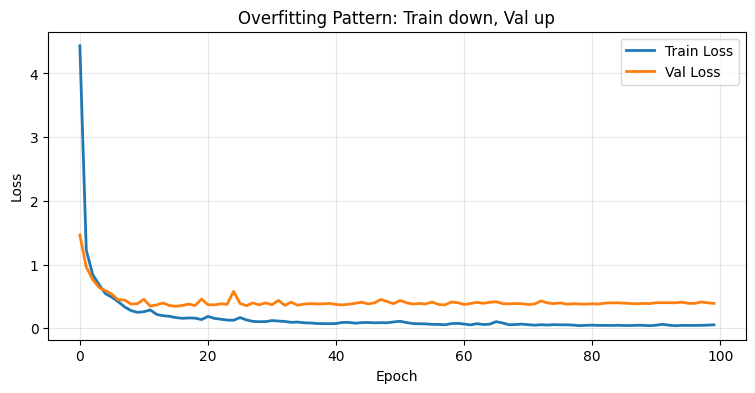

In [13]:
# Loss curve 그리기
plt.figure(figsize=(9, 4))
plt.plot(history_overfit.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history_overfit.history['val_loss'], label='Val Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Overfitting Pattern: Train down, Val up')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**과적합 시그널:**
- Train loss는 계속 감소
- Val loss는 어느 시점부터 *상승*
- 둘 사이 *갭*이 점점 벌어짐

> 💡 **실험 습관**: 새 데이터를 만나면 *과적합을 일부러 한 번 만들어본다*.
> 모델의 "최대 표현력"을 확인한 후, 거기서 정규화로 줄여나가는 게 안전.

---
# Part 3. 정규화

> 정규화(Regularization) = 모델의 *암기 능력*을 약하게 만들어 *일반화 능력*을 높이는 기법

## 비교 실험용 헬퍼 함수

같은 조건에서 4가지 정규화를 비교하기 위한 함수.

In [14]:
def train_and_eval(model, name, epochs=50, callbacks=None):
    '''모델 학습 + 결과 출력 + history 반환'''
    keras.utils.set_random_seed(42)  # 재현성
    history = model.fit(
        X_train_small, y_train_small,
        validation_data=(X_val, y_val),
        epochs=epochs, batch_size=32,
        verbose=0,
        callbacks=callbacks or []
    )
    final_train = history.history['loss'][-1]
    final_val   = history.history['val_loss'][-1]
    print(f'{name:15s} | Train: {final_train:.4f} | Val: {final_val:.4f} | Gap: {final_val - final_train:+.4f}')
    return history

# 결과 저장용
histories = {}

## 3.0 Baseline (정규화 없음) — 비교 기준

In [15]:
keras.utils.set_random_seed(42)
model_base = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1)
])
model_base.compile(optimizer='adam', loss='mse', metrics=['mae'])

histories['Baseline'] = train_and_eval(model_base, 'Baseline')

Baseline        | Train: 0.1037 | Val: 0.3508 | Gap: +0.2471


## 3.1 Dropout

### 직관

```
학습 시: 매 step마다 일부 뉴런을 30% 확률로 무작위 비활성
추론 시: 모두 사용 (Keras가 자동으로 스케일 조정)
```

### 효과
1. **앙상블 효과**: 매번 다른 부분 네트워크가 학습 → 여러 모델의 평균 효과
2. **공의존 방지**: 특정 뉴런 조합에 *의존*하는 패턴을 막음

In [16]:
from keras.layers import Dropout

keras.utils.set_random_seed(42)
model_dropout = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),                              # 30% 비활성
    keras.layers.Dense(128, activation='relu'),
    Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    Dropout(0.3),
    keras.layers.Dense(1)
])
model_dropout.compile(optimizer='adam', loss='mse', metrics=['mae'])

histories['Dropout'] = train_and_eval(model_dropout, 'Dropout')

Dropout         | Train: 0.4818 | Val: 0.4430 | Gap: -0.0388


### 하이퍼파라미터
- `Dropout(rate)`: 보통 0.2 ~ 0.5
- **출력층 직전에는 쓰지 않는다**

## 3.2 L2 Regularization

### 직관

Loss에 *가중치 크기 페널티*를 추가:

```
원래 loss:        L = MSE
L2 추가 loss:     L = MSE + λ · Σ wᵢ²
```

가중치가 클수록 페널티 ↑ → 모델이 작은 가중치 선호 → 단순한 함수 → 과적합 ↓

In [17]:
from keras.regularizers import l2

keras.utils.set_random_seed(42)
reg = l2(0.01)   # λ = 0.01
model_l2 = keras.Sequential([
    keras.layers.Dense(128, activation='relu',
                       kernel_regularizer=reg,
                       input_shape=(X_train.shape[1],)),
    keras.layers.Dense(128, activation='relu', kernel_regularizer=reg),
    keras.layers.Dense(64, activation='relu', kernel_regularizer=reg),
    keras.layers.Dense(1)
])
model_l2.compile(optimizer='adam', loss='mse', metrics=['mae'])

histories['L2'] = train_and_eval(model_l2, 'L2')

L2              | Train: 0.3985 | Val: 0.4704 | Gap: +0.0719


### L1 vs L2

| 종류 | 페널티 | 효과 |
|------|--------|------|
| **L2 (Ridge)** | Σ wᵢ² | 가중치를 *작게* (0에 가깝게) |
| **L1 (Lasso)** | Σ \|wᵢ\| | 가중치를 *정확히 0*으로 (feature 선택) |

신경망에서는 **L2가 표준**.

### 하이퍼파라미터
- `l2(λ)`: λ는 보통 1e-4 ~ 1e-2

## 3.3 Early Stopping

### 직관

Val loss가 *더 이상 개선되지 않으면* 학습을 멈춘다.
**"최선의 시점"에서 자동으로 정지** → 과적합 시점에 도달하기 전에 종료.

In [18]:
from keras.callbacks import EarlyStopping

keras.utils.set_random_seed(42)
model_es = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1)
])
model_es.compile(optimizer='adam', loss='mse', metrics=['mae'])

es = EarlyStopping(
    monitor='val_loss',          # 감시할 지표
    patience=10,                 # 10 epoch 동안 개선 없으면 정지
    restore_best_weights=True    # 최선의 가중치로 복원 (필수!)
)

histories['EarlyStop'] = train_and_eval(model_es, 'EarlyStop', callbacks=[es])
print(f'  → 실제 학습된 epoch 수: {len(histories["EarlyStop"].history["loss"])}')

EarlyStop       | Train: 0.0936 | Val: 0.3737 | Gap: +0.2801
  → 실제 학습된 epoch 수: 48


### 핵심 옵션 3가지

| 옵션 | 의미 | 권장값 |
|------|------|--------|
| `monitor` | 무엇을 볼까 | `'val_loss'` (회귀), `'val_accuracy'` (분류) |
| `patience` | 몇 epoch 참을까 | 10~20 |
| `restore_best_weights` | 최선의 모델로 복원 | **반드시 True** |

### 왜 가장 실용적인가
- **하이퍼파라미터 거의 없음** (patience만 설정)
- **epochs를 크게 잡아도 안전** (학습 시간 자동 단축)
- **다른 정규화와 조합 가능** (서로 충돌하지 않음)

> 💡 **권장**: 새 문제에는 *항상* Early Stopping부터 적용한다.

## 3.4 Batch Normalization

### 직관

각 층의 입력을 *미니배치 단위로 정규화* (평균 0, 분산 1):

```
Dense → BatchNorm → Activation → Dense → BatchNorm → Activation → ...
        ↑↑↑↑↑↑↑↑↑
        매 layer마다 입력 분포를 안정시킴
```

### 왜 효과적인가
1. **학습 안정성**: 각 층의 입력 분포가 일정
2. **약한 정규화 효과**: 미니배치마다 약간씩 다른 통계량 → 일종의 noise
3. **초기값 민감도 ↓**

In [19]:
from keras.layers import BatchNormalization, Activation

keras.utils.set_random_seed(42)
model_bn = keras.Sequential([
    keras.layers.Dense(128, input_shape=(X_train.shape[1],)),  # activation 분리
    BatchNormalization(),
    Activation('relu'),
    keras.layers.Dense(128),
    BatchNormalization(),
    Activation('relu'),
    keras.layers.Dense(64),
    BatchNormalization(),
    Activation('relu'),
    keras.layers.Dense(1)
])
model_bn.compile(optimizer='adam', loss='mse', metrics=['mae'])

histories['BatchNorm'] = train_and_eval(model_bn, 'BatchNorm')

BatchNorm       | Train: 0.1533 | Val: 0.3394 | Gap: +0.1861


> 💡 **순서가 중요**: `Dense → BatchNorm → Activation` 순서가 표준.
> `Dense(activation='relu')`처럼 한 번에 쓰면 BN을 *활성화 후*에 적용하게 되어 효과 감소.

## 3.5 4가지 비교 시각화

5가지 모델(Baseline + 4총사)의 loss curve를 한 번에 비교.

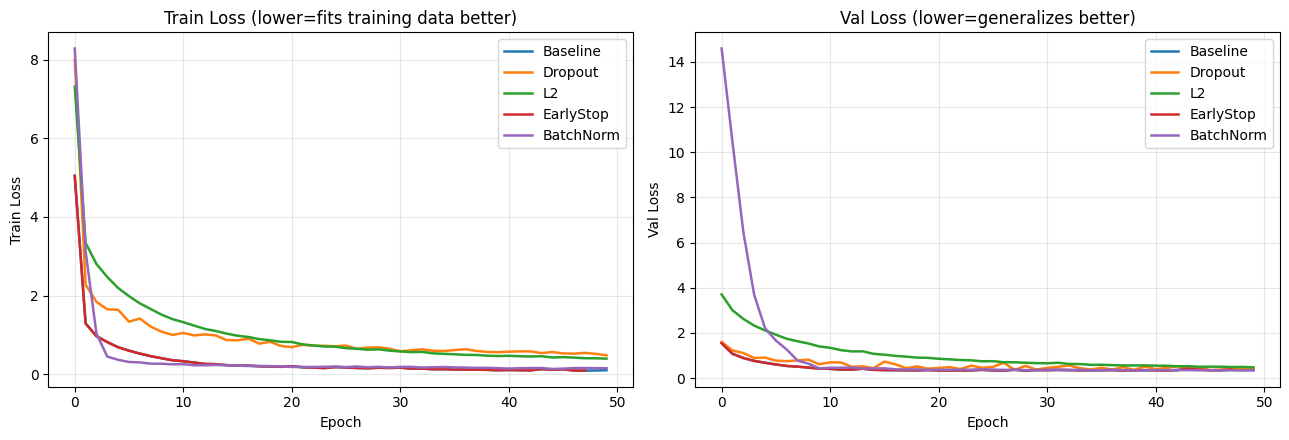

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# 왼쪽: Train Loss
for name, hist in histories.items():
    axes[0].plot(hist.history['loss'], label=name, linewidth=1.8)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Train Loss')
axes[0].set_title('Train Loss (lower=fits training data better)')
axes[0].legend(); axes[0].grid(alpha=0.3)

# 오른쪽: Val Loss
for name, hist in histories.items():
    axes[1].plot(hist.history['val_loss'], label=name, linewidth=1.8)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Loss')
axes[1].set_title('Val Loss (lower=generalizes better)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# 표로 정리
print(f'{"Method":<12} {"Train":>10} {"Val":>10} {"Gap (V-T)":>12}')
print('-' * 46)
for name, hist in histories.items():
    tr = hist.history['loss'][-1]
    vl = hist.history['val_loss'][-1]
    print(f'{name:<12} {tr:>10.4f} {vl:>10.4f} {vl-tr:>+12.4f}')

Method            Train        Val    Gap (V-T)
----------------------------------------------
Baseline         0.1037     0.3508      +0.2471
Dropout          0.4818     0.4430      -0.0388
L2               0.3985     0.4704      +0.0719
EarlyStop        0.0936     0.3737      +0.2801
BatchNorm        0.1533     0.3394      +0.1861


## 3.6 조합 가이드

### 실용적인 적용 순서

```
1) Early Stopping (항상)
2) Loss curve 확인
3) 여전히 과적합이면 → Dropout 또는 L2 추가
4) 학습이 불안정하면 → BatchNormalization 추가
```

### ⚠️ Dropout + BatchNorm 동시 사용

학계에 논쟁이 있다 (서로 간섭 가능). 실무 권장사항:
- 둘 다 쓰려면 `BN → Activation → Dropout` 순서
- 보통은 **둘 중 하나만** 써도 충분

## ✅ Part 3 정리

| 방법 | 핵심 코드 | 효과 |
|------|----------|------|
| **Dropout** | `Dropout(0.3)` | 뉴런 무작위 비활성 → 앙상블 효과 |
| **L2** | `kernel_regularizer=l2(0.01)` | 가중치 작게 → 단순한 함수 |
| **Early Stopping** ⭐ | `EarlyStopping(patience=10)` | 최선 시점 자동 정지 |
| **BatchNorm** | `BatchNormalization()` | 층 입력 정규화 → 학습 안정 |

> **한 줄로**: *Early Stopping은 항상, 나머지는 필요할 때.*

---
# Part 4. 종합 실습

## 4.1 시나리오

**전체 train 데이터**(작은 1000개가 아닌 전체)로 두 모델을 학습 + 비교:
- **Baseline**: 정규화 없음
- **Regularized**: 4총사 모두 적용 (L2 + BN + Dropout + EarlyStopping)

In [22]:
# Baseline (정규화 없음)
keras.utils.set_random_seed(42)
baseline = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1)
])
baseline.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 전체 train 사용 (X_train_small이 아님)
print('Baseline 학습 중...')
hist_base = baseline.fit(X_train, y_train,
                         validation_data=(X_val, y_val),
                         epochs=100, batch_size=32, verbose=0)
print(f'완료. 최종 val loss: {hist_base.history["val_loss"][-1]:.4f}')

Baseline 학습 중...


완료. 최종 val loss: 0.1610


In [23]:
# Regularized (4총사 적용)
keras.utils.set_random_seed(42)
regularized = keras.Sequential([
    keras.layers.Dense(128, kernel_regularizer=l2(0.001),
                       input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),

    keras.layers.Dense(128, kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),

    keras.layers.Dense(64, kernel_regularizer=l2(0.001)),
    Activation('relu'),

    keras.layers.Dense(1)
])
regularized.compile(optimizer='adam', loss='mse', metrics=['mae'])

es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print('Regularized 학습 중...')
hist_reg = regularized.fit(X_train, y_train,
                           validation_data=(X_val, y_val),
                           epochs=100, batch_size=32, verbose=0,
                           callbacks=[es])
print(f'완료. 학습된 epoch: {len(hist_reg.history["loss"])}')
print(f'최종 val loss: {hist_reg.history["val_loss"][-1]:.4f}')

Regularized 학습 중...
완료. 학습된 epoch: 99
최종 val loss: 0.2620


## 4.2 결과 비교

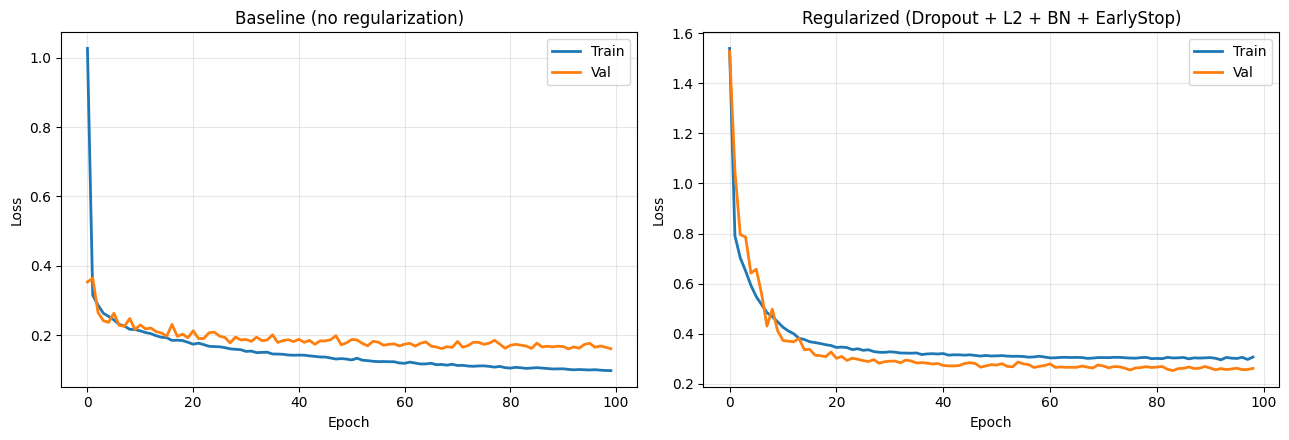

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Baseline
axes[0].plot(hist_base.history['loss'], label='Train', linewidth=2)
axes[0].plot(hist_base.history['val_loss'], label='Val', linewidth=2)
axes[0].set_title('Baseline (no regularization)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Regularized
axes[1].plot(hist_reg.history['loss'], label='Train', linewidth=2)
axes[1].plot(hist_reg.history['val_loss'], label='Val', linewidth=2)
axes[1].set_title('Regularized (Dropout + L2 + BN + EarlyStop)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
# Test 평가 (마지막 한 번만!)
base_loss, base_mae = baseline.evaluate(X_test, y_test, verbose=0)
reg_loss,  reg_mae  = regularized.evaluate(X_test, y_test, verbose=0)

print(f'{"Model":<15} {"Test Loss":>12} {"Test MAE":>12}')
print('-' * 42)
print(f'{"Baseline":<15} {base_loss:>12.4f} {base_mae:>12.4f}')
print(f'{"Regularized":<15} {reg_loss:>12.4f} {reg_mae:>12.4f}')
print()
improvement = (base_mae - reg_mae) / base_mae * 100
print(f'개선율: {improvement:+.1f}%')

Model              Test Loss     Test MAE
------------------------------------------
Baseline              0.1669       0.2758
Regularized           0.2683       0.3432

개선율: -24.4%
